# (Ignore warnings)

In [125]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Includes

In [126]:

from ucimlrepo import fetch_ucirepo, list_available_datasets
from sklearn.datasets import fetch_openml
from tabulate import tabulate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from collections import Counter

In [127]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 50)
  

heart_disease = fetch_ucirepo(id=45) 
  

X = heart_disease.data.features 
y = heart_disease.data.targets 
  
X


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.300,3,0.000,6.000
1,67,1,4,160,286,0,2,108,1,1.500,2,3.000,3.000
2,67,1,4,120,229,0,2,129,1,2.600,2,2.000,7.000
3,37,1,3,130,250,0,0,187,0,3.500,3,0.000,3.000
4,41,0,2,130,204,0,2,172,0,1.400,1,0.000,3.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.200,2,0.000,7.000
299,68,1,4,144,193,1,0,141,0,3.400,2,2.000,7.000
300,57,1,4,130,131,0,0,115,1,1.200,2,1.000,7.000
301,57,0,2,130,236,0,2,174,0,0.000,2,1.000,3.000


Carreguem dataset, guardem variables a X, variable objectiu a y i dataset complet a heart_disease_df

In [128]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


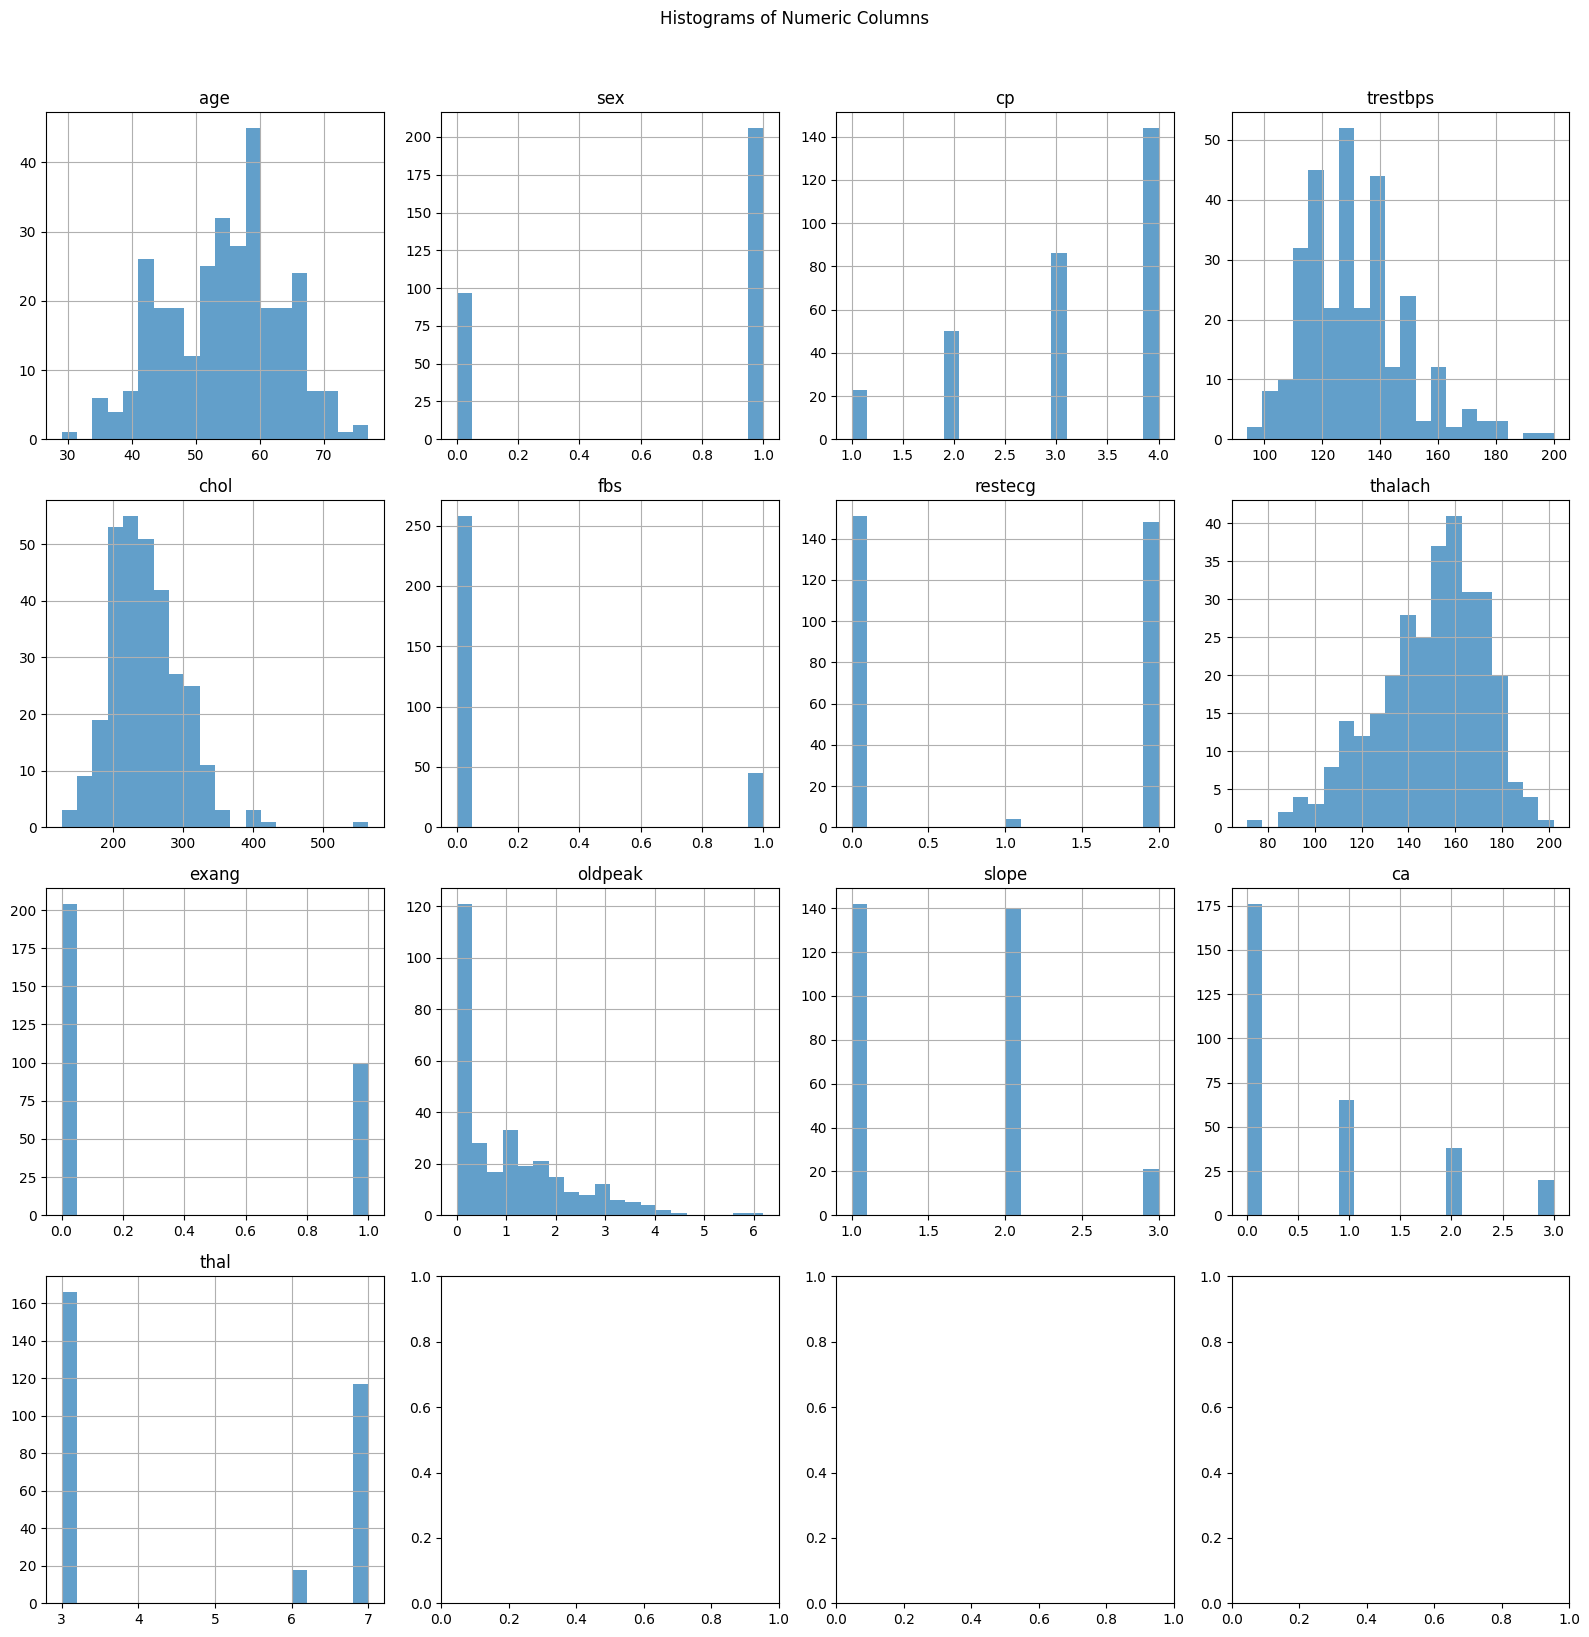

In [129]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Histograms of Numeric Columns', y=1.02)

for i, column in enumerate(X.columns):
    ax = axes[i // 4, i % 4]
    X[column].hist(ax=ax, bins=20, alpha=0.7)
    ax.set_title(column)

plt.tight_layout()
plt.show()


<Axes: >

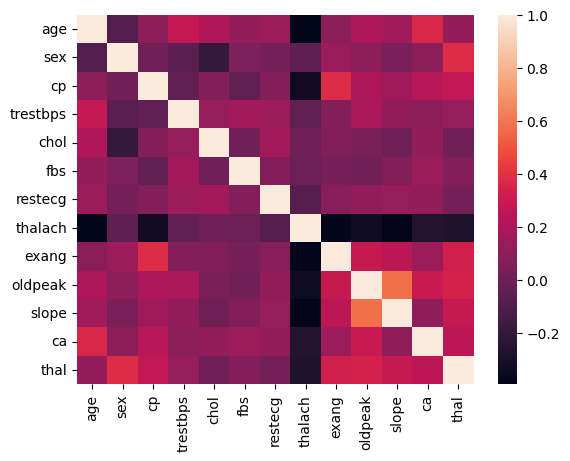

In [130]:
sns.heatmap((X).corr())

Visualitzem la quantitat de NaNs que tenim en la base de dades per columna.

In [131]:
nan_counts = X.isna().sum()
print("Nombre de NaN per columna:")
display(nan_counts)

Nombre de NaN per columna:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Ara mostrem les files que contenen NaN en algun atribut.

In [132]:
display(X[X.isna().any(axis=1)])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
87,53,0,3,128,216,0,2,115,0,0.000,1,0.000,NaN
166,52,1,3,138,223,0,0,169,0,0.000,1,NaN,3.000
192,43,1,4,132,247,1,2,143,1,0.100,2,NaN,7.000
266,52,1,4,128,204,1,0,156,1,1.000,2,0.000,NaN
287,58,1,2,125,220,0,0,144,0,0.400,2,NaN,7.000
302,38,1,3,138,175,0,0,173,0,0.000,1,NaN,3.000


### Preprocessing Pipeline:

* Standaritzar
* Normalitzar
* Tractar NaNs

In [133]:
class NaNsImputer(BaseEstimator, TransformerMixin):
     
    def fit(self, X):
        return self
    
    def transform(self, X):
        imputer = SimpleImputer(strategy='mean')
        X['ca'] = imputer.fit_transform(X[['ca']])
        X['thal'] = imputer.fit_transform(X[['thal']])
        return X

class NaNsDropper(BaseEstimator, TransformerMixin):
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        X = X.dropna()
        return X
    
class Normalizer(BaseEstimator, TransformerMixin):
    
    def fit(self, X):
        return self
    
    def transform(self, X):
        scaler = MinMaxScaler()
        X_transformed = scaler.fit_transform(X)
        return pd.DataFrame(X_transformed, columns=X.columns)


In [134]:
pipe = Pipeline([
    ("NnNsDropper", NaNsDropper()),
    ("Normalizer", Normalizer())
])

X = pipe.fit_transform(X)
y = y.loc[X.index]
print(f'Number of NaNs: {X.isna().sum().sum()}')
X

Number of NaNs: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.708,1.000,0.000,0.481,0.244,1.000,1.000,0.603,0.000,0.371,1.000,0.000,0.750
1,0.792,1.000,1.000,0.623,0.365,0.000,1.000,0.282,1.000,0.242,0.500,1.000,0.000
2,0.792,1.000,1.000,0.245,0.235,0.000,1.000,0.443,1.000,0.419,0.500,0.667,1.000
3,0.167,1.000,0.667,0.340,0.283,0.000,0.000,0.885,0.000,0.565,1.000,0.000,0.000
4,0.250,0.000,0.333,0.340,0.178,0.000,1.000,0.771,0.000,0.226,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.583,0.000,1.000,0.434,0.263,0.000,0.000,0.397,1.000,0.032,0.500,0.000,1.000
293,0.333,1.000,0.000,0.151,0.315,0.000,0.000,0.466,0.000,0.194,0.500,0.000,1.000
294,0.812,1.000,1.000,0.472,0.153,1.000,0.000,0.534,0.000,0.548,0.500,0.667,1.000
295,0.583,1.000,1.000,0.340,0.011,0.000,0.000,0.336,1.000,0.194,0.500,0.333,1.000


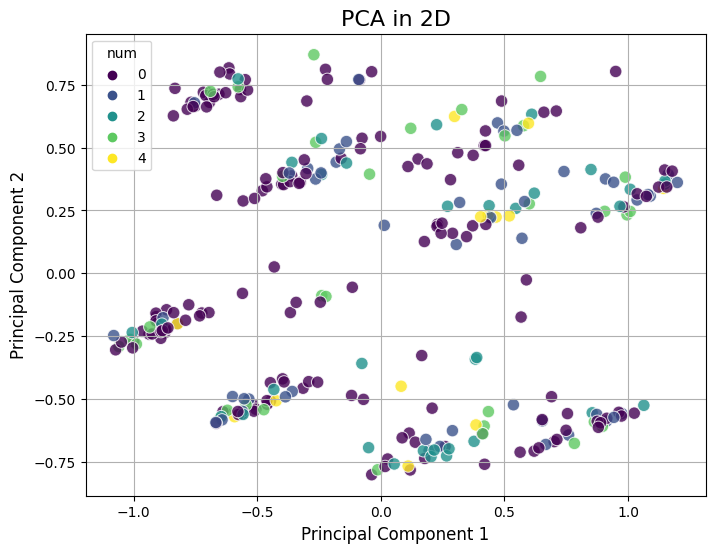

In [135]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'num' is a column in your DataFrame
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create a scatter plot with seaborn for better aesthetics
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y['num'], palette='viridis', edgecolor='w', s=80, alpha=0.8)

# Customize plot
plt.title('PCA in 2D', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='num', loc='best', fontsize=10)
plt.grid(True)

# Show the plot
plt.show()


# ID3

In [136]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,*,value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

In [137]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split=min_samples_split
        self.max_depth=max_depth
        self.n_features=n_features
        self.root=None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1],self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # check the stopping criteria
        if (depth>=self.max_depth or n_labels==1 or n_samples<self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # find the best split
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        return Node(best_feature, best_thresh, left, right)


    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                # calculate the information gain
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold


    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)

        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # calculate the weighted avg. entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l/n) * e_l + (n_r/n) * e_r

        # calculate the IG
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log(p) for p in ps if p>0])


    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


qcut

In [138]:
display(heart_disease.variables)

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


In [154]:
df_num = X[['sex', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']]
df_num = X.drop(columns=['sex', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'])
display(df_num, df_cat)

,age,cp,fbs,restecg,exang,slope,thal
0,0.708,0.000,1.000,1.000,0.000,1.000,0.750
1,0.792,1.000,0.000,1.000,1.000,0.500,0.000
2,0.792,1.000,0.000,1.000,1.000,0.500,1.000
3,0.167,0.667,0.000,0.000,0.000,1.000,0.000
4,0.250,0.333,0.000,1.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...
292,0.583,1.000,0.000,0.000,1.000,0.500,1.000
293,0.333,0.000,0.000,0.000,0.000,0.500,1.000
294,0.812,1.000,1.000,0.000,0.000,0.500,1.000
295,0.583,1.000,0.000,0.000,1.000,0.500,1.000


,sex,trestbps,chol,thalach,oldpeak,ca
0,1.000,0.481,0.244,0.603,0.371,0.000
1,1.000,0.623,0.365,0.282,0.242,1.000
2,1.000,0.245,0.235,0.443,0.419,0.667
3,1.000,0.340,0.283,0.885,0.565,0.000
4,0.000,0.340,0.178,0.771,0.226,0.000
...,...,...,...,...,...,...
292,0.000,0.434,0.263,0.397,0.032,0.000
293,1.000,0.151,0.315,0.466,0.194,0.000
294,1.000,0.472,0.153,0.534,0.548,0.667
295,1.000,0.340,0.011,0.336,0.194,0.333
